In [1]:
import sys
from maxent_model import run_maxent_species
from joblib import cpu_count

sys.path.insert(0, 'dataprep')
from species_manifest import load_species_manifest, get_species_entry

In [2]:
parambasedir = '/mnt/f/biodiversity/param_csvs'
baseoutputdir = '/mnt/f/biodiversity'
sp = 'Protonotaria citrea'
aoi = 'mav_counties_4326.parquet'

manifest = load_species_manifest()
entry = get_species_entry(manifest, sp)
spgroup = entry['spgroup']
excel_group = entry['excel_group']

/mnt/f/biodiversity/ppp_paramsoutput/protonotaria_citrea
Reading: /mnt/f/biodiversity/param_csvs/protonotaria_citrea_subset0.csv
Reading: /mnt/f/biodiversity/param_csvs/protonotaria_citrea_subset1.csv


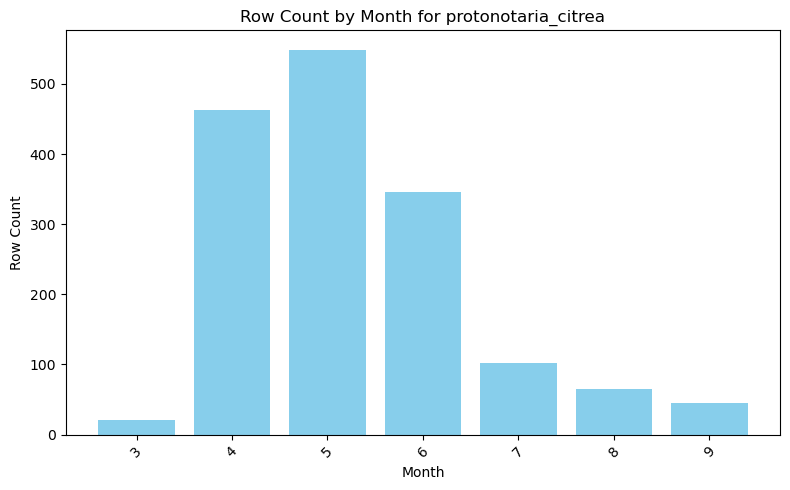

Reading: /mnt/f/biodiversity/param_csvs/background_avian.csv


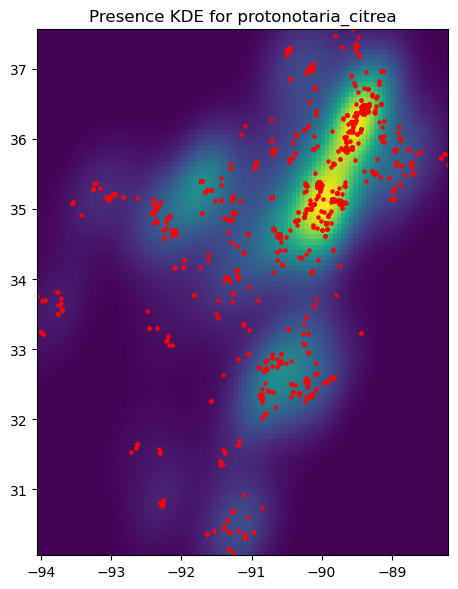

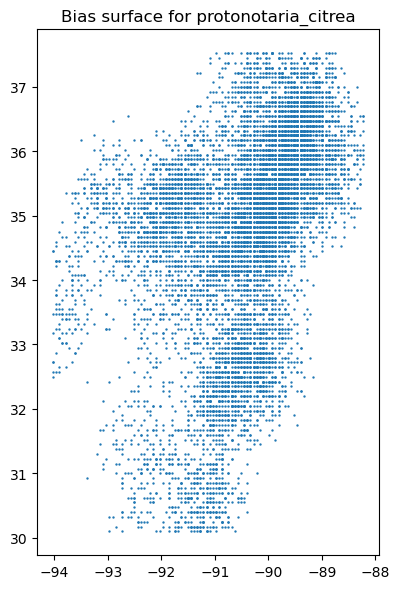

/home/mike/miniforge3/envs/biodiversity/lib/python3.12/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


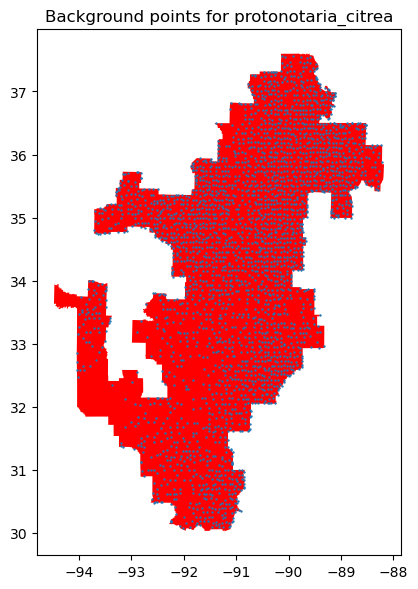

Total presence points: 1591
Total background points: 2833


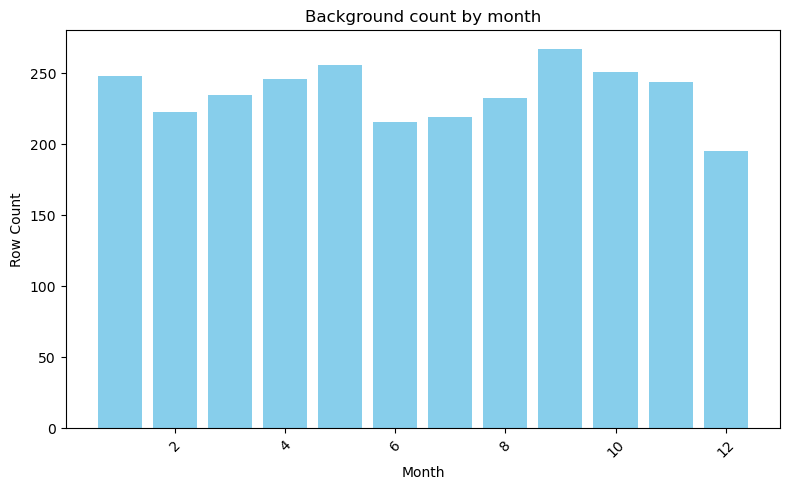

Fold type: GeographicKFold


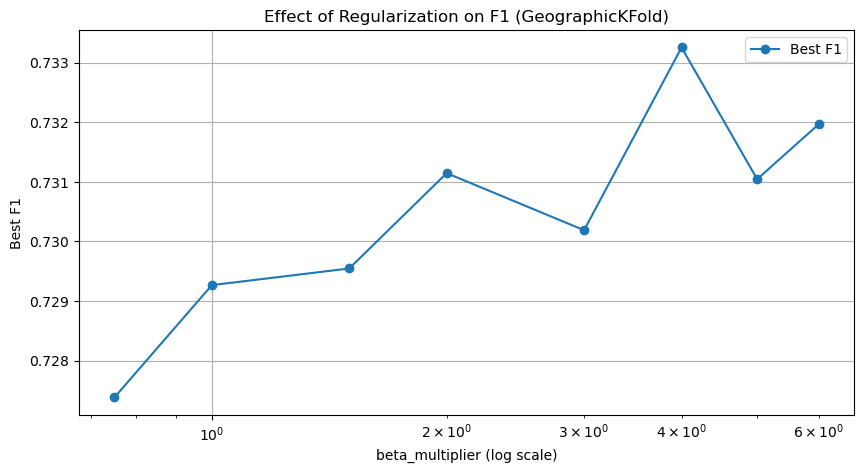

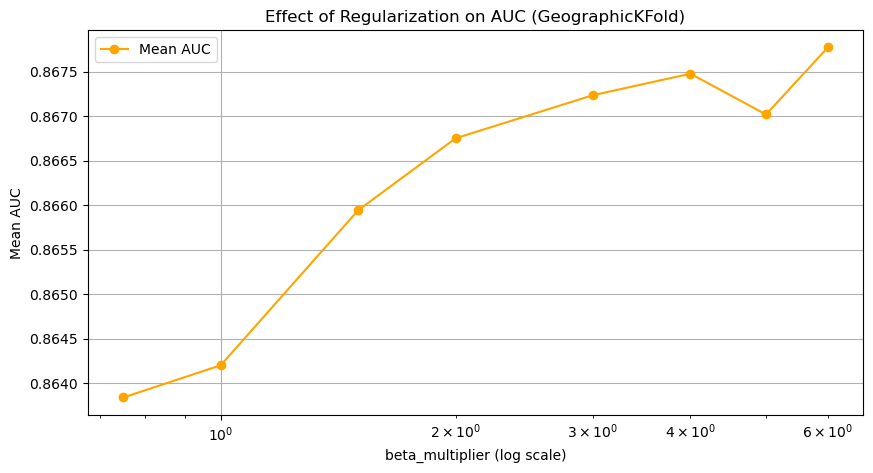

Selected beta_multiplier=6.0 (CV mean_auc=0.8678)
Final tuned model (beta_multiplier=6.0)
AUC=0.9434  Precision=0.7508  Recall=0.9145  F1=0.8246
Best threshold=0.1422  Log-loss=0.3229  Prevalence=0.3596


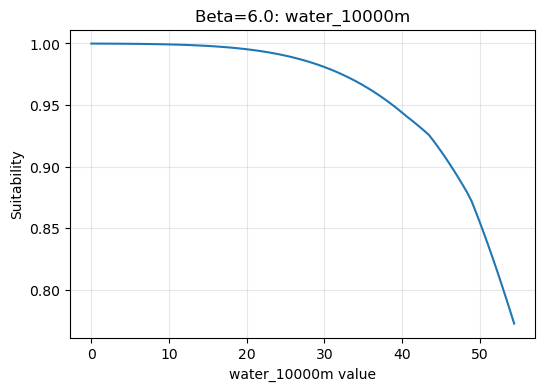

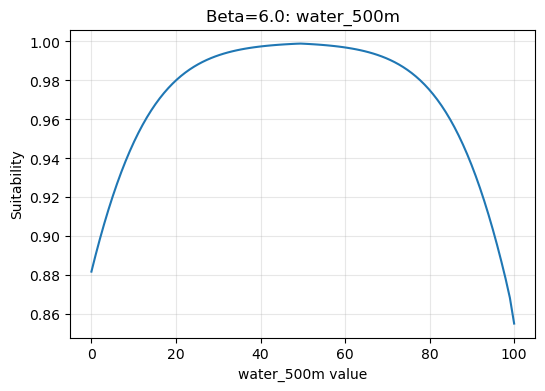

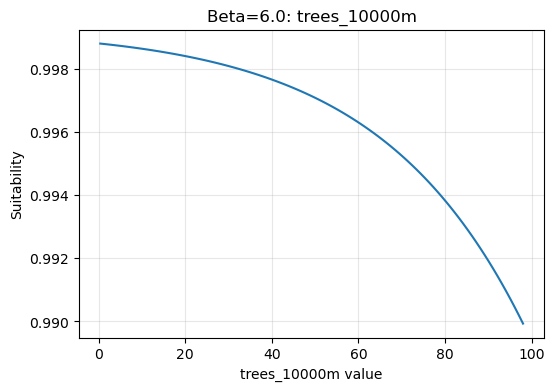

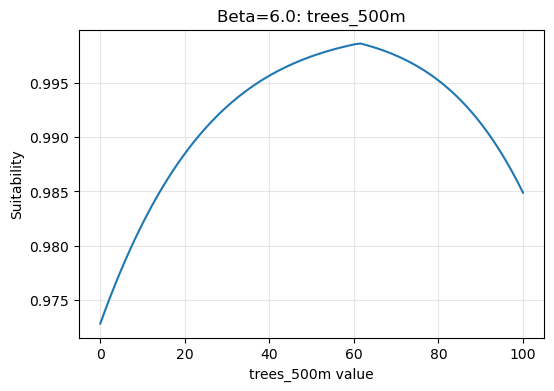

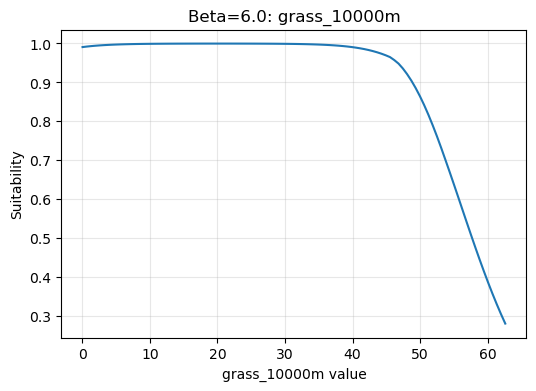

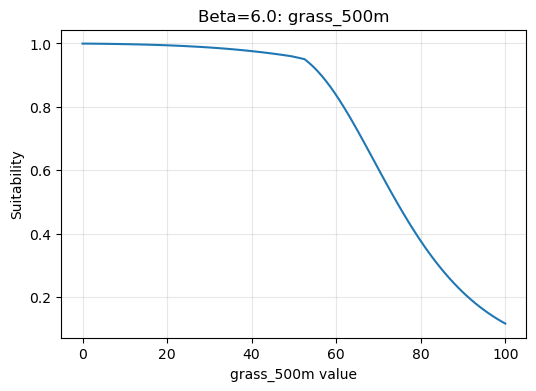

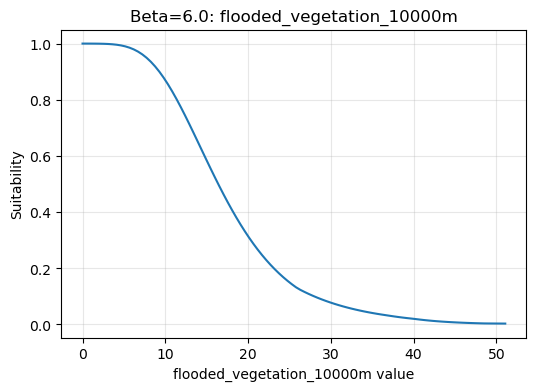

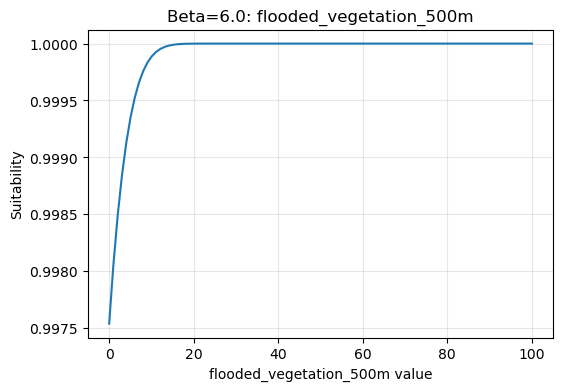

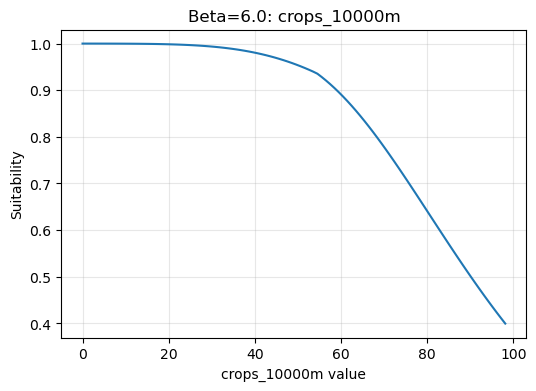

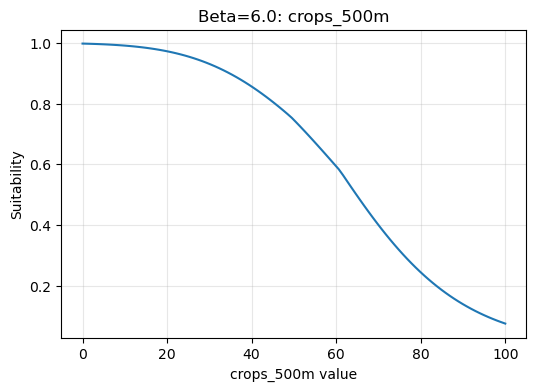

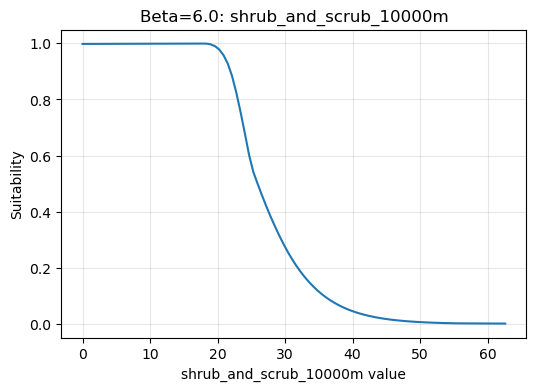

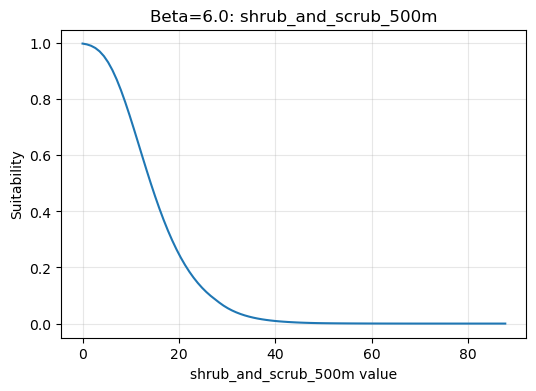

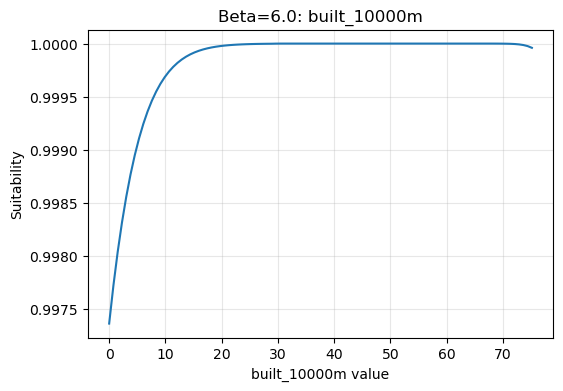

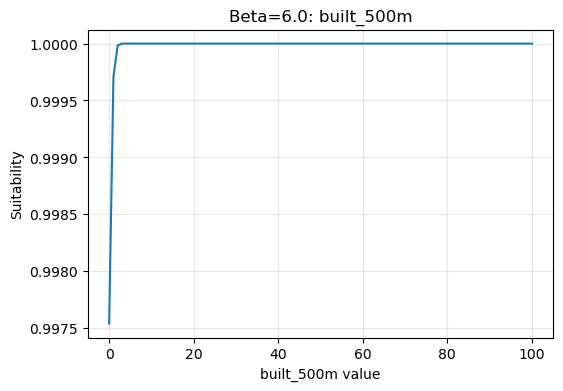

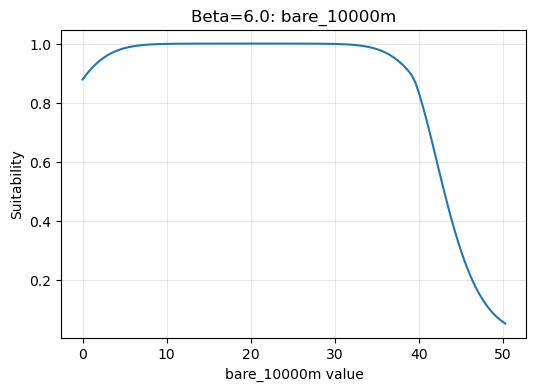

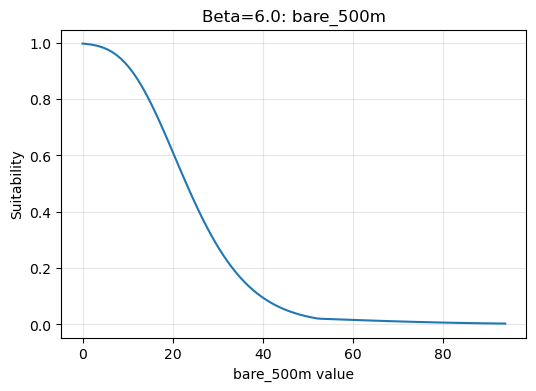

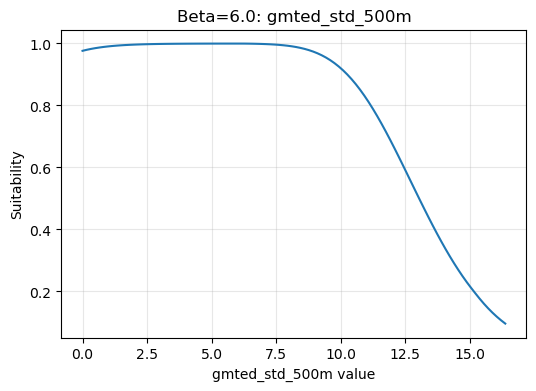

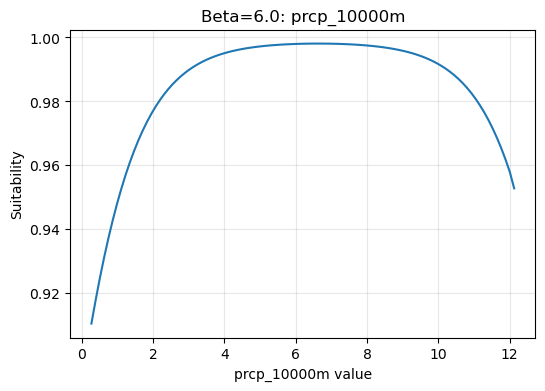

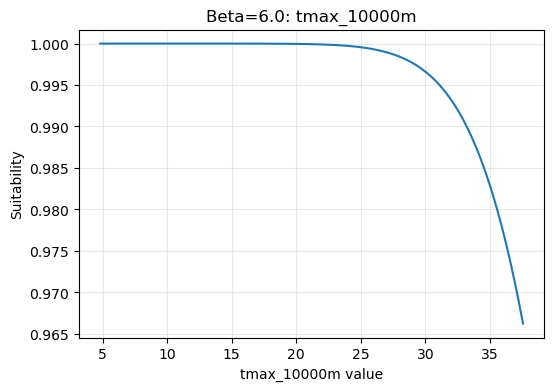

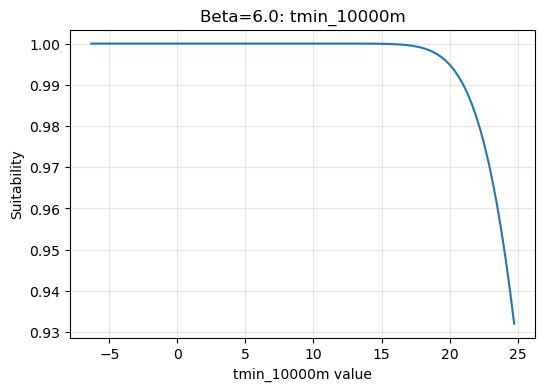

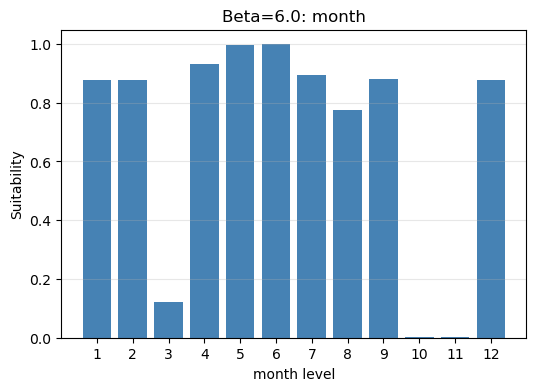

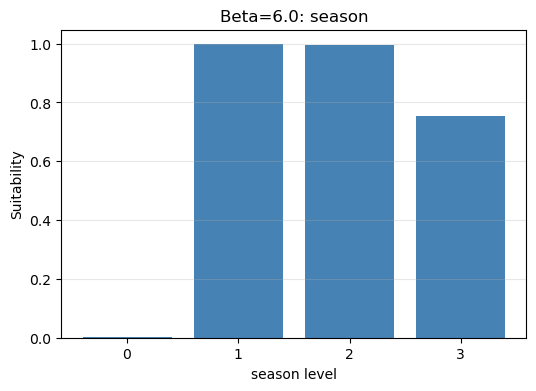

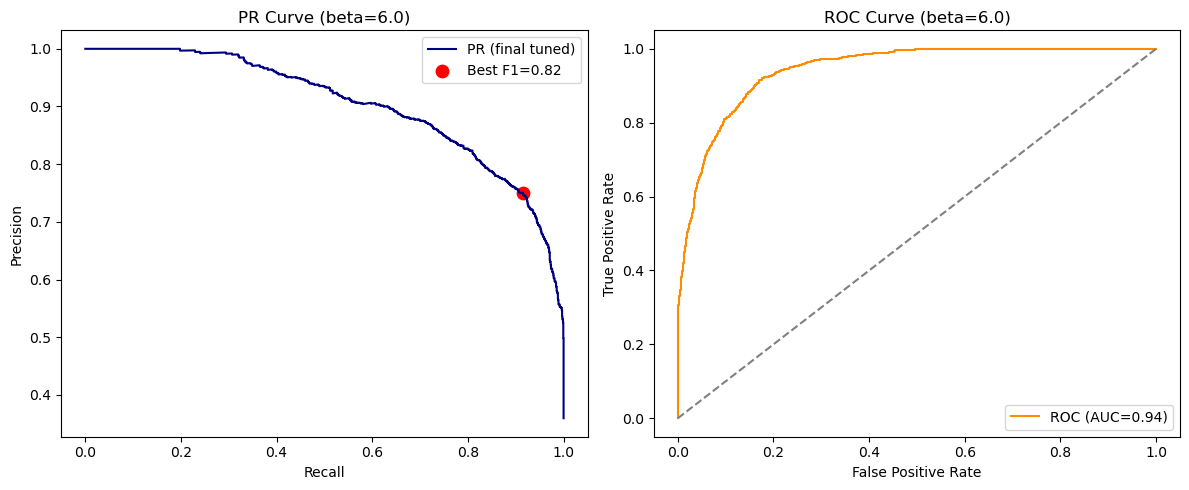

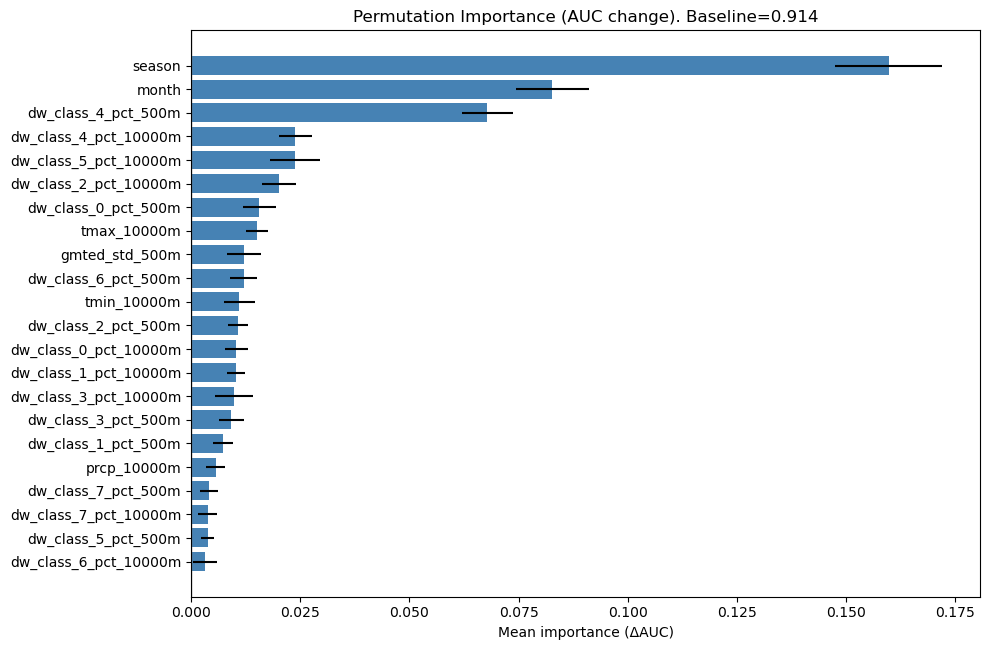

Tuned final MaxEnt (PPP-equivalent) model saved, with diagnostics & importance.


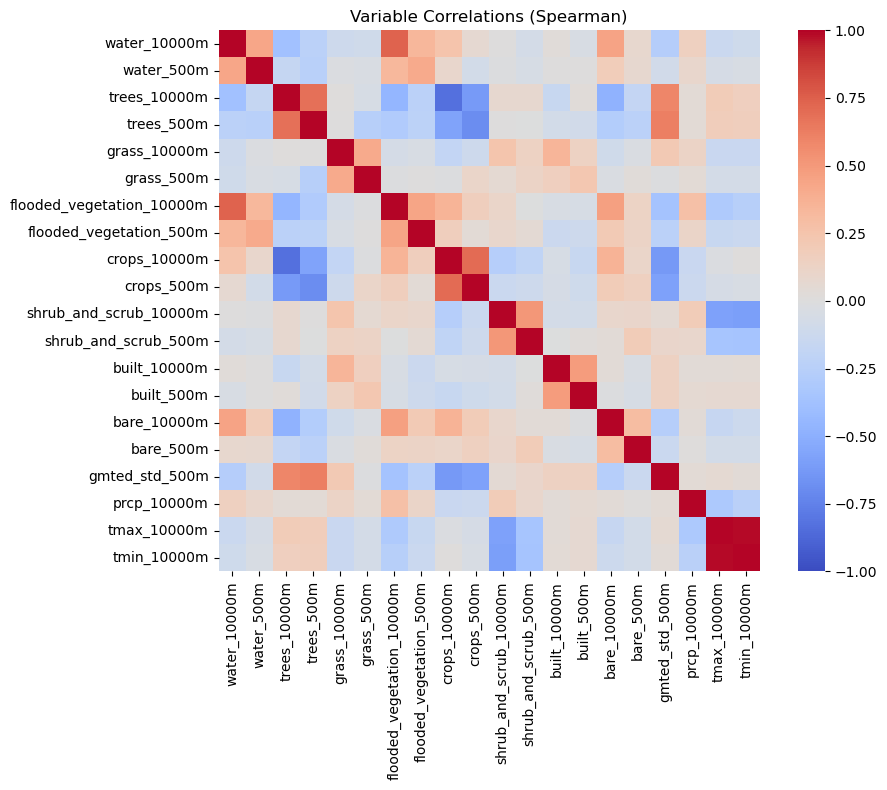

{'best_beta': 6.0, 'selection_metric': 'mean_auc', 'final_auc': 0.9434318038969203, 'final_f1': 0.8245962023951714, 'final_precision': 0.7507739938080495, 'final_recall': 0.9145191703331238, 'final_threshold': np.float64(0.14219845872398496), 'final_logloss': 0.3229294470666935, 'prevalence': np.float64(0.359629294755877), 'cv_name': 'GeographicKFold', 'reg_results': [{'beta_multiplier': 0.75, 'best_f1': 0.7273802478754919, 'mean_auc': 0.8638388824205803}, {'beta_multiplier': 1.0, 'best_f1': 0.7292654023452529, 'mean_auc': 0.8642004710201421}, {'beta_multiplier': 1.5, 'best_f1': 0.729544777841198, 'mean_auc': 0.8659415990533951}, {'beta_multiplier': 2.0, 'best_f1': 0.7311446312674819, 'mean_auc': 0.8667508922985412}, {'beta_multiplier': 3.0, 'best_f1': 0.7301869986110685, 'mean_auc': 0.8672351311759334}, {'beta_multiplier': 4.0, 'best_f1': 0.7332528661272264, 'mean_auc': 0.8674765694246519}, {'beta_multiplier': 5.0, 'best_f1': 0.731042653530087, 'mean_auc': 0.8670184893018661}, {'beta_

In [3]:
results = run_maxent_species(
    sp=sp,
    spgroup=spgroup,
    parambasedir=parambasedir,
    baseoutputdir=baseoutputdir,
    aoi_filename=aoi,
    excel_group=excel_group,
    n_cpus=cpu_count(),
    batch_mode=False,
    inner_parallel=True,
    selection_metric='mean_auc',
)
print(results)